# 自动测checkpoint大小，带宽等

In [ ]:
!python /home/users/u0001609/benchmark_ckpt_params.py \
    --model_name Qwen/Qwen3-1.7B \
    --disk_paths /lvs0/rccs-hpbdrt/minqiu/local_models/Test \
    --t_step 0.128

Loading Qwen/Qwen3-1.7B to measure checkpoint size...
Loading checkpoint shards: 100%|██████████████████| 2/2 [00:53<00:00, 26.56s/it]

Model: Qwen/Qwen3-1.7B
  Param bytes: 3.44 GB
  torch.save file: 3.44 GB
  Num tensors: 310

--- GPU → CPU bandwidth (PCIe) ---
  Testing with 3.44 GB transfer...
  Bandwidth: 44.88 GB/s
  Median copy time: 0.077s

--- CPU → disk bandwidth: /lvs0/rccs-hpbdrt/minqiu/local_models/Test ---
  Testing with 3.44 GB write...
  Raw write: 0.11 GB/s (30.240s)
  torch.save: 0.11 GB/s (30.283s)

--- Optimal parameters (t_step = 0.128s) ---

  Storage: /lvs0/rccs-hpbdrt/minqiu/local_models/Test (B_disk = 0.11 GB/s)
    t_copy (GPU→CPU): 0.077s
    t_persist (CPU→disk): 30.283s
    n_lag: 237.2 steps
    K_min: 237 steps

Results saved to ckpt_bench_results.json


# DISCARDED! Calibrate Closed-Form Replay (Fully Parallel)

Closed-form 将 ZO-SGD 递推展开为独立项之和:
```
p_n = sp[0] × p_0 − Σ_{t} sp[t+1] × lr_t × grad_t × z_t
```
每项独立 → W 个 worker 并行计算 partial sum。

**CPU 瓶颈: 内存带宽饱和**
- 每 worker 每 term I/O: read z + read partial + write partial ≈ Ψ × (replay_elem + 2 × accum_elem)
- DDR4 双通道 ~50 GB/s, DDR5 ~75 GB/s → 通常 W=2-4 饱和
- W 过大 → 带宽竞争 + 内存压力，反而更慢

**GPU 瓶颈: SM 饱和**
- 大模型单个 .add_() 已用满所有 SM
- 多 stream 主要收益: overlap z 生成和累加 → 通常 W=2-4

**Per-worker memory** = Ψ × (accum_elem_size + replay_elem_size)
- 1.7B 参数, CPU/mixed: 1.7B × (4+4) = 13.6 GB / worker
- 1.7B 参数, GPU/fp16:  1.7B × (2+2) = 6.8 GB / worker

设置: `CLOSEDFORM_RECOVERY=1 CLOSEDFORM_WORKERS=W CLOSEDFORM_PRECISION=mode` （可选参数详见README）

In [ ]:
"""Benchmark optimal W for closed-form replay across precision modes."""
import sys, os, time, threading, psutil
import torch
sys.path.insert(0, '/home/users/u0001609/NonStopZO2')
from transformers import AutoModelForCausalLM

# ======================== CONFIG ========================
MODEL_NAME = "Qwen/Qwen3-1.7B"
MAX_W = 8       # max workers to test
N_ITERS = 10    # iterations per W level，为了测试计时稳定，和实际 replay 多少步无关
# ========================================================

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)
state = {n: p.data for n, p in model.named_parameters() if p.requires_grad}
total_numel = sum(p.numel() for p in state.values())
del model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

avail_cpu = psutil.virtual_memory().available
print(f"Model: {MODEL_NAME}")
print(f"Trainable params: {total_numel:,} ({total_numel * 2 / 1e9:.2f} GB fp16)")
print(f"CPU RAM available: {avail_cpu / 1e9:.1f} GB")
if torch.cuda.is_available():
    print(f"GPU RAM free: {torch.cuda.mem_get_info()[0] / 1e9:.1f} GB")

# ======================== PRECISION CONFIGS ========================
# (name, device, accum_elem_bytes, replay_elem_bytes, accum_dtype, replay_dtype)
# CPU: replay always fp32 (torch.normal fp16 on CPU is 22x slower)
# GPU: replay in native dtype (fp16 fast on GPU)
configs = [
    ("CPU/mixed",  "cpu",  4, 4, torch.float32, torch.float32),   # accum=fp32, z=fp32
    ("CPU/fp16",   "cpu",  2, 4, torch.float16, torch.float32),   # accum=fp16, z=fp32
    ("CPU/fp32",   "cpu",  4, 4, torch.float32, torch.float32),   # accum=fp32, z=fp32
]
if torch.cuda.is_available():
    configs += [
        ("GPU/mixed",  "cuda", 4, 2, torch.float32, torch.float16),  # accum=fp32, z=fp16
        ("GPU/fp16",   "cuda", 2, 2, torch.float16, torch.float16),  # accum=fp16, z=fp16
        ("GPU/fp32",   "cuda", 4, 4, torch.float32, torch.float32),  # accum=fp32, z=fp32
    ]

# ======================== BENCHMARK CORE ========================
test_numel = min(total_numel, 50_000_000)

def bench_cpu(accum_dt, replay_dt, max_w, n_iters):
    cast = (accum_dt != replay_dt)
    results = {}
    for W in range(1, max_w + 1):
        partials = [torch.zeros(test_numel, dtype=accum_dt) for _ in range(W)]
        bar = threading.Barrier(W + 1)
        times = [0.0] * W
        def fn(wid):
            p = partials[wid]
            for _ in range(3):
                z = torch.randn(test_numel, dtype=replay_dt)
                p.add_(z.to(accum_dt) if cast else z, alpha=1.0)
            bar.wait()
            t0 = time.perf_counter()
            for _ in range(n_iters):
                z = torch.randn(test_numel, dtype=replay_dt)
                p.add_(z.to(accum_dt) if cast else z, alpha=1.0)
            times[wid] = time.perf_counter() - t0
            bar.wait()
        ts = [threading.Thread(target=fn, args=(i,)) for i in range(W)]
        for t in ts: t.start()
        bar.wait(); bar.wait()
        for t in ts: t.join()
        results[W] = W * n_iters / max(times)
        del partials
    return results

def bench_gpu(accum_dt, replay_dt, max_w, n_iters):
    cast = (accum_dt != replay_dt)
    results = {}
    for W in range(1, max_w + 1):
        try:
            ps = [torch.zeros(test_numel, dtype=accum_dt, device='cuda') for _ in range(W)]
        except RuntimeError:
            break
        ss = [torch.cuda.Stream() for _ in range(W)]
        for wid in range(W):
            with torch.cuda.stream(ss[wid]):
                z = torch.randn(test_numel, dtype=replay_dt, device='cuda')
                ps[wid].add_(z.to(accum_dt) if cast else z, alpha=1.0)
        torch.cuda.synchronize()
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_iters):
            for wid in range(W):
                with torch.cuda.stream(ss[wid]):
                    z = torch.randn(test_numel, dtype=replay_dt, device='cuda')
                    ps[wid].add_(z.to(accum_dt) if cast else z, alpha=1.0)
        torch.cuda.synchronize()
        results[W] = W * n_iters / (time.perf_counter() - t0)
        del ps, ss; torch.cuda.empty_cache()
    return results

# ======================== RUN ========================
print(f"\n{'='*72}")
print(f"Benchmark: z_gen + accumulation throughput  |  test_numel={test_numel:,}")
print(f"{'='*72}")

summary = {}
for name, dev, acc_e, rep_e, acc_dt, rep_dt in configs:
    pw_bytes = total_numel * (acc_e + rep_e)
    pw_GB = pw_bytes / 1e9
    if dev == 'cpu':
        W_mem = max(1, int(avail_cpu * 0.5 / pw_bytes))
    else:
        W_mem = max(1, int(torch.cuda.mem_get_info()[0] * 0.8 / pw_bytes))
    eff_max = min(MAX_W, W_mem)

    if dev == 'cpu':
        res = bench_cpu(acc_dt, rep_dt, eff_max, N_ITERS)
    else:
        res = bench_gpu(acc_dt, rep_dt, eff_max, N_ITERS)

    best = max(res, key=res.get) if res else 1
    summary[name] = (best, pw_GB, W_mem)

    print(f"\n--- {name}  (per_worker={pw_GB:.1f}GB, W_mem_limit={W_mem}) ---")
    print(f"  {'W':>3} | {'terms/s':>10} | {'vs W=1':>7} | {'total_mem':>10} |")
    print(f"  {'-'*3}-+-{'-'*10}-+-{'-'*7}-+-{'-'*10}-+----")
    base = res.get(1, 1)
    for w in sorted(res):
        sp = res[w] / base
        tm = w * pw_GB
        tag = " <-- best" if w == best else ""
        print(f"  {w:3d} | {res[w]:10.1f} | {sp:6.2f}x | {tm:8.1f} GB |{tag}")

# ======================== SUMMARY ========================
print(f"\n{'='*72}")
print("SUMMARY: Recommended W")
print(f"{'='*72}")
for name, (best, pw, wm) in summary.items():
    print(f"  {name:15s}: W = {best}   (per_worker={pw:.1f}GB, max_by_mem={wm})")
print(f"\nUsage:")
print(f"  CLOSEDFORM_RECOVERY=1  CLOSEDFORM_WORKERS=<W>  CLOSEDFORM_PRECISION=<mixed|fp16|fp32>")

/hs/work0/home/users/u0001609/.miao/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading checkpoint shards: 100%|██████████| 2/2 [00:52<00:00, 26.27s/it]


Model: Qwen/Qwen3-1.7B
Trainable params: 1,720,574,976 (3.44 GB fp16)
CPU RAM available: 226.3 GB
GPU RAM free: 99.4 GB

Benchmark: z_gen + accumulation throughput  |  test_numel=50,000,000

--- CPU/mixed  (per_worker=13.8GB, W_mem_limit=8) ---
    W |    terms/s |  vs W=1 |  total_mem |
  ----+------------+---------+------------+----
    1 |        6.9 |   1.00x |     13.8 GB |
    2 |        7.1 |   1.02x |     27.5 GB |
    3 |        7.1 |   1.02x |     41.3 GB |
    4 |        7.1 |   1.02x |     55.1 GB |
    5 |        7.1 |   1.03x |     68.8 GB |
    6 |        7.1 |   1.03x |     82.6 GB | <-- best
    7 |        7.1 |   1.02x |     96.4 GB |
    8 |        7.1 |   1.02x |    110.1 GB |

--- CPU/fp16  (per_worker=10.3GB, W_mem_limit=10) ---
    W |    terms/s |  vs W=1 |  total_mem |
  ----+------------+---------+------------+----
    1 |        6.9 |   1.00x |     10.3 GB |
    2 |        7.1 |   1.03x |     20.6 GB |
    3 |        7.1 |   1.03x |     31.0 GB |
    4 |     

# **sbatch**

MODEL=Qwen/Qwen3-1.7B TASK=SST2 MODE=ft LR=1e-7 EPS=1e-3 STEPS=1000 EVAL_STEPS=100 SAVE_STEPS=1 DO_EVAL=0 LOG_BASED_CKPT=0 LOG_BASED_REPLAY_DEVICE=cuda  LOG_BASED_SIMULATE_PERTURBATION=1 LOG_BASED_RESUME="/lvs0/rccs-hpbdrt/minqiu/ZO_ckpt/144954-SST2-Qwen3-1.7B-mezo-ft-1e-7-1e-3-0/checkpoint-1" sbatch /home/users/u0001609/NonStopZO2/example/mezo_runner/submit_mezo_a100.sbatch


In [4]:
TRAIN_NAME = "122"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

RUN_CMD = f"""
TRAIN_NAME={TRAIN_NAME} FORCE_FSYNC=1 RESET_OUTPUT_DIR=1 \
MODEL=Qwen/Qwen3-8B TASK=SST2 TRAIN=99999999 NUM_EPOCHS=1 STEPS=100 DEV='' \
BS=64 MAX_LENGTH=2048 DTYPE=fp32 \
ZO_METHOD=mezo-sgd MODE=ft LR=1e-7 EPS=1e-3 \
LOG_BASED_CKPT=0 SAVE_STEPS=1 \
ENABLE_SHADOW=1 SHADOW_COMMIT_INTERVAL=8 SHADOW_FLAT_COMMIT=1 \
SHADOW_PIPELINE=1 SHADOW_PIPELINE_WORKERS=1 \
SHADOW_CONSUMER_THREADS=50 SHADOW_RESERVE_THREADS=1 \
DO_EVAL=0 EVAL_STRATEGY=no ZO_TRACE=1 ZO_RNG_DEVICE=zo_rng \
FAILURE_TYPE=soft GPU_FAIL_STEP=50 INSTANT_RECOVER=1 \
TRANSFORMERS_OFFLINE=1 \
bash /home/users/u0001609/NonStopZO2/example/mezo_runner/mezo.sh
"""


!{RUN_CMD}

!cp /tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl ~/zo_trace/zo_trace_{TRAIN_NAME}.jsonl

Using GPU: 0
INSTANT_RECOVER=1, ignoring RESET_OUTPUT_DIR and keeping OUTPUT_DIR: /tmp/ZO_ckpt/122
========== Configuration ==========
TAG: mezo-ft-1e-7-1e-3-0
BS: 64, LR: 1e-7, EPS: 1e-3, SEED: 0
MAX_LENGTH: 2048
STEPS: 100, NUM_EPOCHS: 1, EVAL_STRATEGY: no, EVAL_STEPS: 4000, SAVE_STEPS: 1, LOGGING_STEPS: 10
MODE: ft, DTYPE: fp32, DO_EVAL: 0, ZO_METHOD: mezo-sgd
OUTPUT_DIR: /tmp/ZO_ckpt/122
ZO_TRACE_PATH: /tmp/ZO_ckpt/122/zo_trace.jsonl
ZO_SHM_DIR: /dev/shm/ZO_ckpt/122
--- Log-Based Checkpoint ---
LOG_BASED_CKPT: 0 (-1=disabled, 0=log-based, N>=1=full+log)
ENABLE_SHADOW: 1
INSTANT_RECOVER: 1
FAILURE_TYPE: soft
ASYNC_ANCHOR: 0
GPU_FAIL_STEP: 50
Extra args:  --log_based_ckpt 0 --enable_shadow --instant_recover --gpu_fail_step 50 --overwrite_output_dir --zo_rng_device zo_rng --no_eval 
2026-04-06 07:58:44,109 - INFO - PyTorch version 2.10.0 available.
OurArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler'

In [6]:
from pathlib import Path
import sys, importlib

TRAIN_NAME = "122"
TRACE_FILE = f"/tmp/ZO_ckpt/{TRAIN_NAME}/zo_trace.jsonl"

REPO_ROOT = Path("/home/users/u0001609/NonStopZO2")
sys.path.insert(0, str(REPO_ROOT / "tools"))

import visualize_trace as vt
vt = importlib.reload(vt)

trace = vt.load_trace(TRACE_FILE)
summary = vt.summarize_trace(trace)
vt.print_summary(summary)

=== Trace Overview ===
total_wall_s: 1152.738

=== Named Time Metrics ===
checkpoint_total: total_s=2.289 avg_s=0.023 count=100
t_step: total_s=1111.127 avg_s=11.224 count=99
t_step_warmup: total_s=10.248 avg_s=10.248 count=1
t_l: total_ms=7.213 avg_ms=0.072 count=100
t_d2h: missing
t_persist: total_s=1.797 avg_s=0.004 count=400
t_r: total_s=0.748 avg_s=0.374 steady_avg_s=0.440 cold_start_s=0.000 count=2
t_rc: total_s=247.976 avg_s=2.530 count=98
t_cp: total_s=14.572 avg_s=0.152 count=98
L_disk: total_s=367.856 avg_s=367.856 count=1
  T_import               =  18.209s (  5.0%)
  T_main_setup           =   5.569s (  1.5%)
  T_config               =   0.007s (  0.0%)
  T_from_pretrained      = 238.175s ( 64.7%) [from_pretrained:Qwen/Qwen3-8B]
  T_zo_init              =   0.002s (  0.0%)
  T_tokenizer            =   0.171s (  0.0%)
  T_tokenize_data        =  28.686s (  7.8%)
  T_trainer_init         =   1.529s (  0.4%)
  T_callback_setup       =   0.002s (  0.0%)
  T_hf_inner            

/hs/work0/home/users/u0001609/.miao/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ThreadProbe: Qwen/Qwen3-8B
  output_dir=/home/users/u0001609/ZO_probes
  log=/home/users/u0001609/ZO_probes/Qwen_Qwen3-8B_ThreadProbe.log


Loading checkpoint shards: 100%|██████████| 5/5 [00:05<00:00,  1.18s/it]



Model: 399 params, 32.76 GB
C = 255, t_train = 9.986s
[BenchCurves] pid=925685 cores=256 C=255 points=23 range=[10..117] warmup=1 measure=2
[BenchCurves] t_gen(generator=10) = 13.394s  [1/23] (n=2)
[BenchCurves] t_gen(generator=15) = 10.438s  [2/23] (n=2)
[BenchCurves] t_gen(generator=20) = 8.041s  [3/23] (n=2)
[BenchCurves] t_gen(generator=25) = 6.538s  [4/23] (n=2)
[BenchCurves] t_gen(generator=30) = 5.505s  [5/23] (n=2)
[BenchCurves] t_gen(generator=35) = 4.780s  [6/23] (n=2)
[BenchCurves] t_gen(generator=40) = 4.240s  [7/23] (n=2)
[BenchCurves] t_gen(generator=45) = 3.808s  [8/23] (n=2)
[BenchCurves] t_gen(generator=50) = 3.494s  [9/23] (n=2)
[BenchCurves] t_gen(generator=55) = 3.296s  [10/23] (n=2)
[BenchCurves] t_gen(generator=60) = 3.003s  [11/23] (n=2)
[BenchCurves] t_gen(generator=65) = 2.740s  [12/23] (n=2)
[BenchCurves] t_gen(generator=70) = 2.706s  [13/23] (n=2)
[BenchCurves] t_gen(generator=75) = 2.888s  [14/23] (n=2)
[BenchCurves] t_gen(generator=80) = 3.095s  [15/23] (n

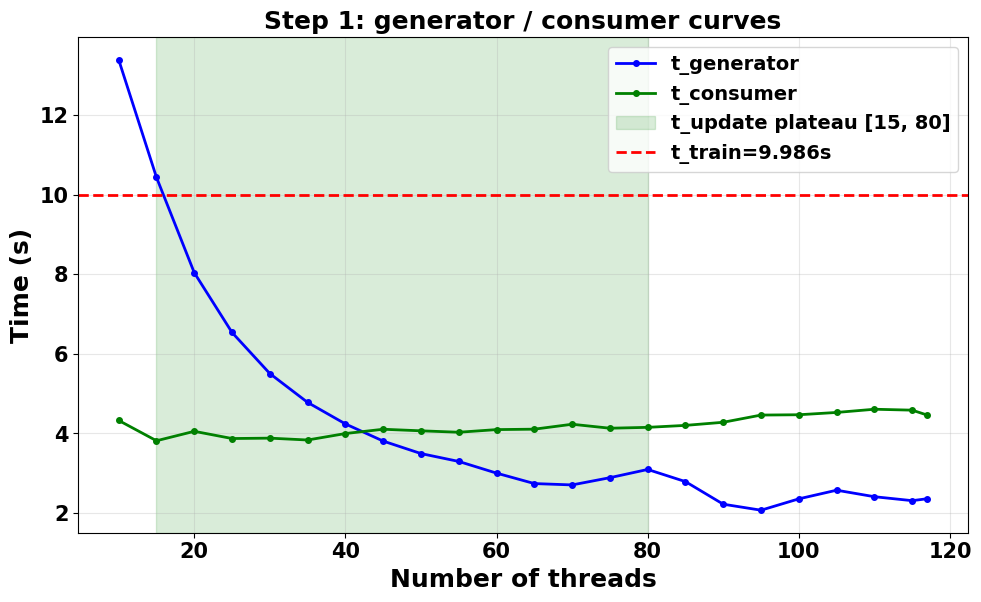

[plot] saved scan → /home/users/u0001609/ZO_probes/Qwen_Qwen3-8B_ThreadProbe_scan.pdf


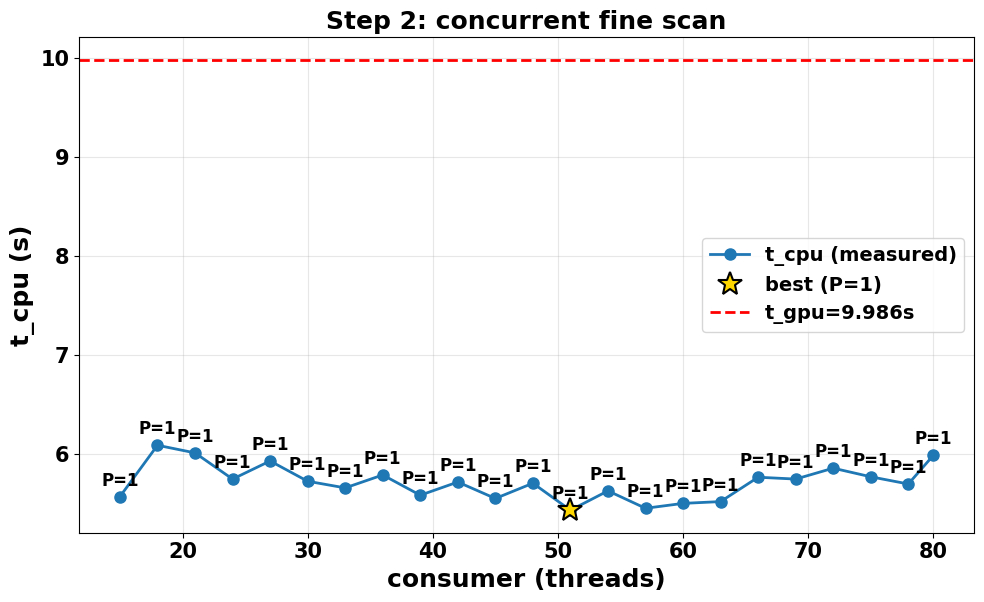

In [3]:
"""ThreadProbe: one-shot calibration (Step 1 + Step 2 + Step 3 + plots)."""
import sys, importlib
sys.path.insert(0, '/home/users/u0001609/NonStopZO2')
sys.path.insert(0, '/home/users/u0001609/NonStopZO2/tools')

import thread_probe as tp
importlib.reload(tp)

probe = tp.run_probe(
    model_name='Qwen/Qwen3-8B',
    gpu_step_s=9.986,           # 训练每步时间（秒）← 从训练日志填入
    output_dir='/home/users/u0001609/ZO_probes',
    reserve_cores=1,
    core_start=10,
    core_stop=117,              # None → 使用 C - 1
    core_step=5,
    n_warmup=1,
    n_measure=2,
    plateau_threshold=1.10,
    consumer_step=3,
    test_n_steps=2,
    test_n_warmup=1,
    fig_width=10,
    font_size=12,
)